# Transformers

In [18]:
import pandas as pd
import numpy as np
import joblib, os, warnings
warnings.filterwarnings("ignore")

from sentence_transformers import SentenceTransformer
from sklearn.decomposition import LatentDirichletAllocation, PCA
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

GOLD, RED, DARK_RED = "#D4AF37", "#C0392B", "#8B0000"
BG, PANEL_BG, TEXT  = "#F5F0E8", "#EDE8DE", "#1A1A1A"

df = pd.read_csv("data/master_dataset.csv")
print(f"Dataset: {df.shape[0]} peliculas, {df['ceremony_year'].nunique()} ceremonias "
      f"({df['ceremony_year'].min()}-{df['ceremony_year'].max()})")
print(f"Ganadoras: {df['won_best_picture'].sum()} | Nominadas no ganadoras: {(df['won_best_picture']==0).sum()}")


Dataset: 315 peliculas, 49 ceremonias (1978-2026)
Ganadoras: 48 | Nominadas no ganadoras: 267


In [19]:
N_TOPICS = 10

vectorizer = CountVectorizer(
    stop_words="english",
    max_df=0.85,
    min_df=3,
    max_features=4000,
    ngram_range=(1, 2),      # unigramas + bigramas
)
X_counts = vectorizer.fit_transform(df["synopsis"].fillna(""))
vocab    = vectorizer.get_feature_names_out()

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=42,
    max_iter=30,
    learning_method="batch",
)
topic_dist = lda.fit_transform(X_counts)   # (n_films, N_TOPICS)

# Top palabras por tema
N_TOP = 10
topic_labels = []
print("── Temas descubiertos ─────────────────────────────────────────────")
for i, comp in enumerate(lda.components_):
    top_words = [vocab[j] for j in comp.argsort()[-N_TOP:][::-1]]
    label = f"T{i}: {' · '.join(top_words[:3])}"
    topic_labels.append(label)
    print(f"  {label}")
    print(f"     {' | '.join(top_words)}\n")


── Temas descubiertos ─────────────────────────────────────────────
  T0: love · young · dr
     love | young | dr | family | old | help | couple | space | year old | year

  T1: love · young · woman
     love | young | woman | wife | new | mission | son | american | life | story

  T2: life · men · story
     life | men | story | new | film | world | death | team | based | son

  T3: new · life · young
     new | life | young | father | people | family | queen | century | home | man

  T4: life · takes · soon
     life | takes | soon | children | world | trip | land | class | working | men

  T5: old · year · father
     old | year | father | time | year old | story | years | life | war | man

  T6: family · story · true
     family | story | true | daughter | american | life | forced | relationship | true story | live

  T7: war · world · world war
     war | world | world war | ii | life | war ii | young | story | family | man

  T8: love · story · american
     love | story | ameri

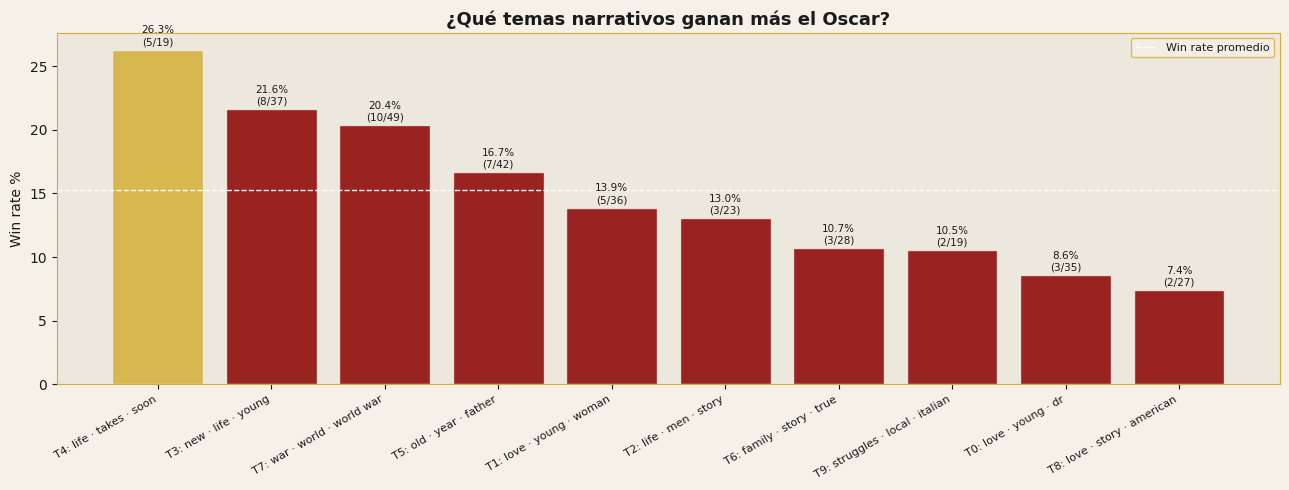

In [20]:
df["dominant_topic"] = topic_dist.argmax(axis=1)

win_rate = (
    df.groupby("dominant_topic")
    .agg(win_rate=("won_best_picture", "mean"),
         n=("won_best_picture", "count"),
         n_wins=("won_best_picture", "sum"))
    .reset_index()
    .sort_values("win_rate", ascending=False)
)

fig, ax = plt.subplots(figsize=(13, 5))
labels = [topic_labels[t] for t in win_rate["dominant_topic"]]
rates  = win_rate["win_rate"].values * 100
colors = [GOLD if r == rates.max() else DARK_RED for r in rates]

bars = ax.bar(range(len(labels)), rates, color=colors, alpha=0.85, edgecolor=BG)
ax.axhline(df["won_best_picture"].mean() * 100, color="white",
           linestyle="--", linewidth=1, label="Win rate promedio")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=8, color=TEXT)
ax.set_ylabel("Win rate %", color=TEXT)
ax.set_title("¿Qué temas narrativos ganan más el Oscar?", color=TEXT,
             fontsize=13, fontweight="bold")
ax.tick_params(colors=TEXT)
ax.set_facecolor(PANEL_BG)
ax.legend(fontsize=8, facecolor=BG, edgecolor=GOLD, labelcolor=TEXT)
for spine in ax.spines.values(): spine.set_edgecolor(GOLD)

for bar, r, row in zip(bars, rates, win_rate.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{r:.1f}%\n({row.n_wins}/{row.n})", ha="center", va="bottom",
            fontsize=7.5, color=TEXT)

fig.patch.set_facecolor(BG)
plt.tight_layout()
plt.savefig("img/topic_winrate.png", dpi=130, bbox_inches="tight", facecolor=BG)
plt.show()


In [21]:
os.makedirs("models", exist_ok=True)
EMB_PATH = "models/synopsis_embeddings.npy"

if os.path.exists(EMB_PATH):
    embeddings = np.load(EMB_PATH)
    print(f"Embeddings cargados: {embeddings.shape}")
else:
    print("Generando embeddings (puede tardar unos minutos)...")
    embedder   = SentenceTransformer("all-mpnet-base-v2")
    embeddings = embedder.encode(
        df["synopsis"].fillna("").tolist(),
        batch_size=32,
        show_progress_bar=True,
        normalize_embeddings=True,
    )
    np.save(EMB_PATH, embeddings)
    print(f"Embeddings guardados: {embeddings.shape}")


Embeddings cargados: (315, 768)


In [22]:
train_years = list(range(1978, 2019))   # 41 años  ~250 films
val_years   = list(range(2019, 2022))   # 3 años   ~30 films
test_years  = list(range(2022, 2026))   # 4 años   ~40 films

train_mask    = df["ceremony_year"].isin(train_years)
val_mask      = df["ceremony_year"].isin(val_years)
test_mask     = df["ceremony_year"].isin(test_years)
trainval_mask = train_mask | val_mask

X_topic = topic_dist    # distribuciones LDA ya son features interpretables
y       = df["won_best_picture"].values

X_top_tr = X_topic[train_mask.values];  E_tr = embeddings[train_mask.values];  y_tr = y[train_mask.values]
X_top_vl = X_topic[val_mask.values];    E_vl = embeddings[val_mask.values];    y_vl = y[val_mask.values]
X_top_tv = X_topic[trainval_mask.values]; E_tv = embeddings[trainval_mask.values]; y_tv = y[trainval_mask.values]
X_top_te = X_topic[test_mask.values];   E_te = embeddings[test_mask.values]

print(f"Train:  {train_mask.sum()} films  ({min(train_years)}-{max(train_years)})")
print(f"Val:    {val_mask.sum()}  films  ({min(val_years)}-{max(val_years)})")
print(f"Test:   {test_mask.sum()}  films  ({min(test_years)}-{max(test_years)})")


Train:  241 films  (1978-2018)
Val:    25  films  (2019-2021)
Test:   39  films  (2022-2025)


In [23]:
def percentile_score(probs_all, df_sub, years):
    """Percentil promedio de la ganadora — 1.0 = siempre #1."""
    scores = []
    dr = df_sub.reset_index(drop=True)
    for year in years:
        m  = dr["ceremony_year"] == year
        p  = probs_all[m.values]
        pn = p / p.sum()
        win = dr.loc[m, "won_best_picture"].values == 1
        if win.sum() == 0: continue
        scores.append((pn < pn[win][0]).mean())
    return np.mean(scores)

best_score, best_params = 0, {}

for n_emb in [5, 10, 20]:
    pca    = PCA(n_components=n_emb, random_state=42)
    sc_emb = StandardScaler()
    sc_top = StandardScaler()

    E_tr_r = sc_emb.fit_transform(pca.fit_transform(E_tr))
    E_vl_r = sc_emb.transform(pca.transform(E_vl))
    T_tr_r = sc_top.fit_transform(X_top_tr)
    T_vl_r = sc_top.transform(X_top_vl)

    X_tr_h = np.hstack([T_tr_r, E_tr_r])
    X_vl_h = np.hstack([T_vl_r, E_vl_r])

    for C in [0.01, 0.1, 1.0, 5.0]:
        lr = LogisticRegression(C=C, class_weight="balanced",
                                max_iter=2000, random_state=42)
        lr.fit(X_tr_h, y_tr)
        sc = percentile_score(lr.predict_proba(X_vl_h)[:, 1], df[val_mask], val_years)
        if sc > best_score:
            best_score  = sc
            best_params = {"n_emb": n_emb, "C": C}

print(f"Mejor Val score: {best_score:.3f}  |  n_emb={best_params['n_emb']}, C={best_params['C']}")


Mejor Val score: 0.556  |  n_emb=5, C=1.0


In [24]:
n_emb, C = best_params["n_emb"], best_params["C"]

# --- Modelo final (train+val → test) ---
pca_f    = PCA(n_components=n_emb, random_state=42)
sc_emb_f = StandardScaler(); sc_top_f = StandardScaler()
X_tv_h   = np.hstack([sc_top_f.fit_transform(X_top_tv),
                       sc_emb_f.fit_transform(pca_f.fit_transform(E_tv))])
X_te_h   = np.hstack([sc_top_f.transform(X_top_te),
                       sc_emb_f.transform(pca_f.transform(E_te))])
lr_final = LogisticRegression(C=C, class_weight="balanced", max_iter=2000, random_state=42)
lr_final.fit(X_tv_h, y_tv)

# --- Modelo val (solo train → val, para visualizar) ---
pca_v    = PCA(n_components=n_emb, random_state=42)
sc_emb_v = StandardScaler(); sc_top_v = StandardScaler()
X_tr_hv  = np.hstack([sc_top_v.fit_transform(X_top_tr),
                       sc_emb_v.fit_transform(pca_v.fit_transform(E_tr))])
X_vl_hv  = np.hstack([sc_top_v.transform(X_top_vl),
                       sc_emb_v.transform(pca_v.transform(E_vl))])
lr_val   = LogisticRegression(C=C, class_weight="balanced", max_iter=2000, random_state=42)
lr_val.fit(X_tr_hv, y_tr)

# --- Probabilidades normalizadas por año ---
def assign_probs(probs_raw, df_sub, years, col="prob"):
    out = df_sub.copy().reset_index(drop=True)
    for year in years:
        m = out["ceremony_year"] == year
        p = probs_raw[m.values]; out.loc[m, col] = p / p.sum()
    return out

df_val_plot  = assign_probs(lr_val.predict_proba(X_vl_hv)[:, 1],  df[val_mask],  val_years)
df_test_plot = assign_probs(lr_final.predict_proba(X_te_h)[:, 1], df[test_mask], test_years)

# --- Resultados ---
def print_results(df_plot, years, label):
    ok_total = 0
    print(f"\n── {label} ─────────────────────────")
    for year in years:
        yd   = df_plot[df_plot["ceremony_year"] == year]
        pred = yd.sort_values("prob", ascending=False).iloc[0]["nominated_title"]
        real = yd[yd["won_best_picture"] == 1]["nominated_title"].values[0]
        wp   = yd[yd["won_best_picture"] == 1]["prob"].values[0]
        ok   = pred == real; ok_total += ok
        print(f"  {year} | Ganadora: {real:<40} Pred: {pred:<40} {wp:.1%}  {'OK' if ok else 'X'}")
    print(f"  Accuracy: {ok_total}/{len(years)} = {ok_total/len(years):.1%}")

print_results(df_val_plot,  val_years,  "Validacion (2019-2021)")
print_results(df_test_plot, test_years, "Test (2022-2025)")

# Guardar
joblib.dump(lr_final,   "models/lr_topics_oscar.pkl")
joblib.dump(pca_f,      "models/pca_topics.pkl")
joblib.dump(lda,        "models/lda_oscar.pkl")
joblib.dump(vectorizer, "models/vectorizer_lda.pkl")
print("\nModelos guardados.")



── Validacion (2019-2021) ─────────────────────────
  2019 | Ganadora: Green Book                               Pred: Bohemian Rhapsody                        8.5%  X
  2020 | Ganadora: Parasite                                 Pred: 1917                                     12.4%  X
  2021 | Ganadora: Nomadland                                Pred: The Trial of the Chicago 7               17.8%  X
  Accuracy: 0/3 = 0.0%

── Test (2022-2025) ─────────────────────────
  2022 | Ganadora: CODA                                     Pred: Don't Look Up                            12.1%  X
  2023 | Ganadora: Everything Everywhere All at Once        Pred: Tár                                      6.0%  X
  2024 | Ganadora: Oppenheimer                              Pred: Barbie                                   13.3%  X
  2025 | Ganadora: Anora                                    Pred: Wicked                                   7.9%  X
  Accuracy: 0/4 = 0.0%

Modelos guardados.


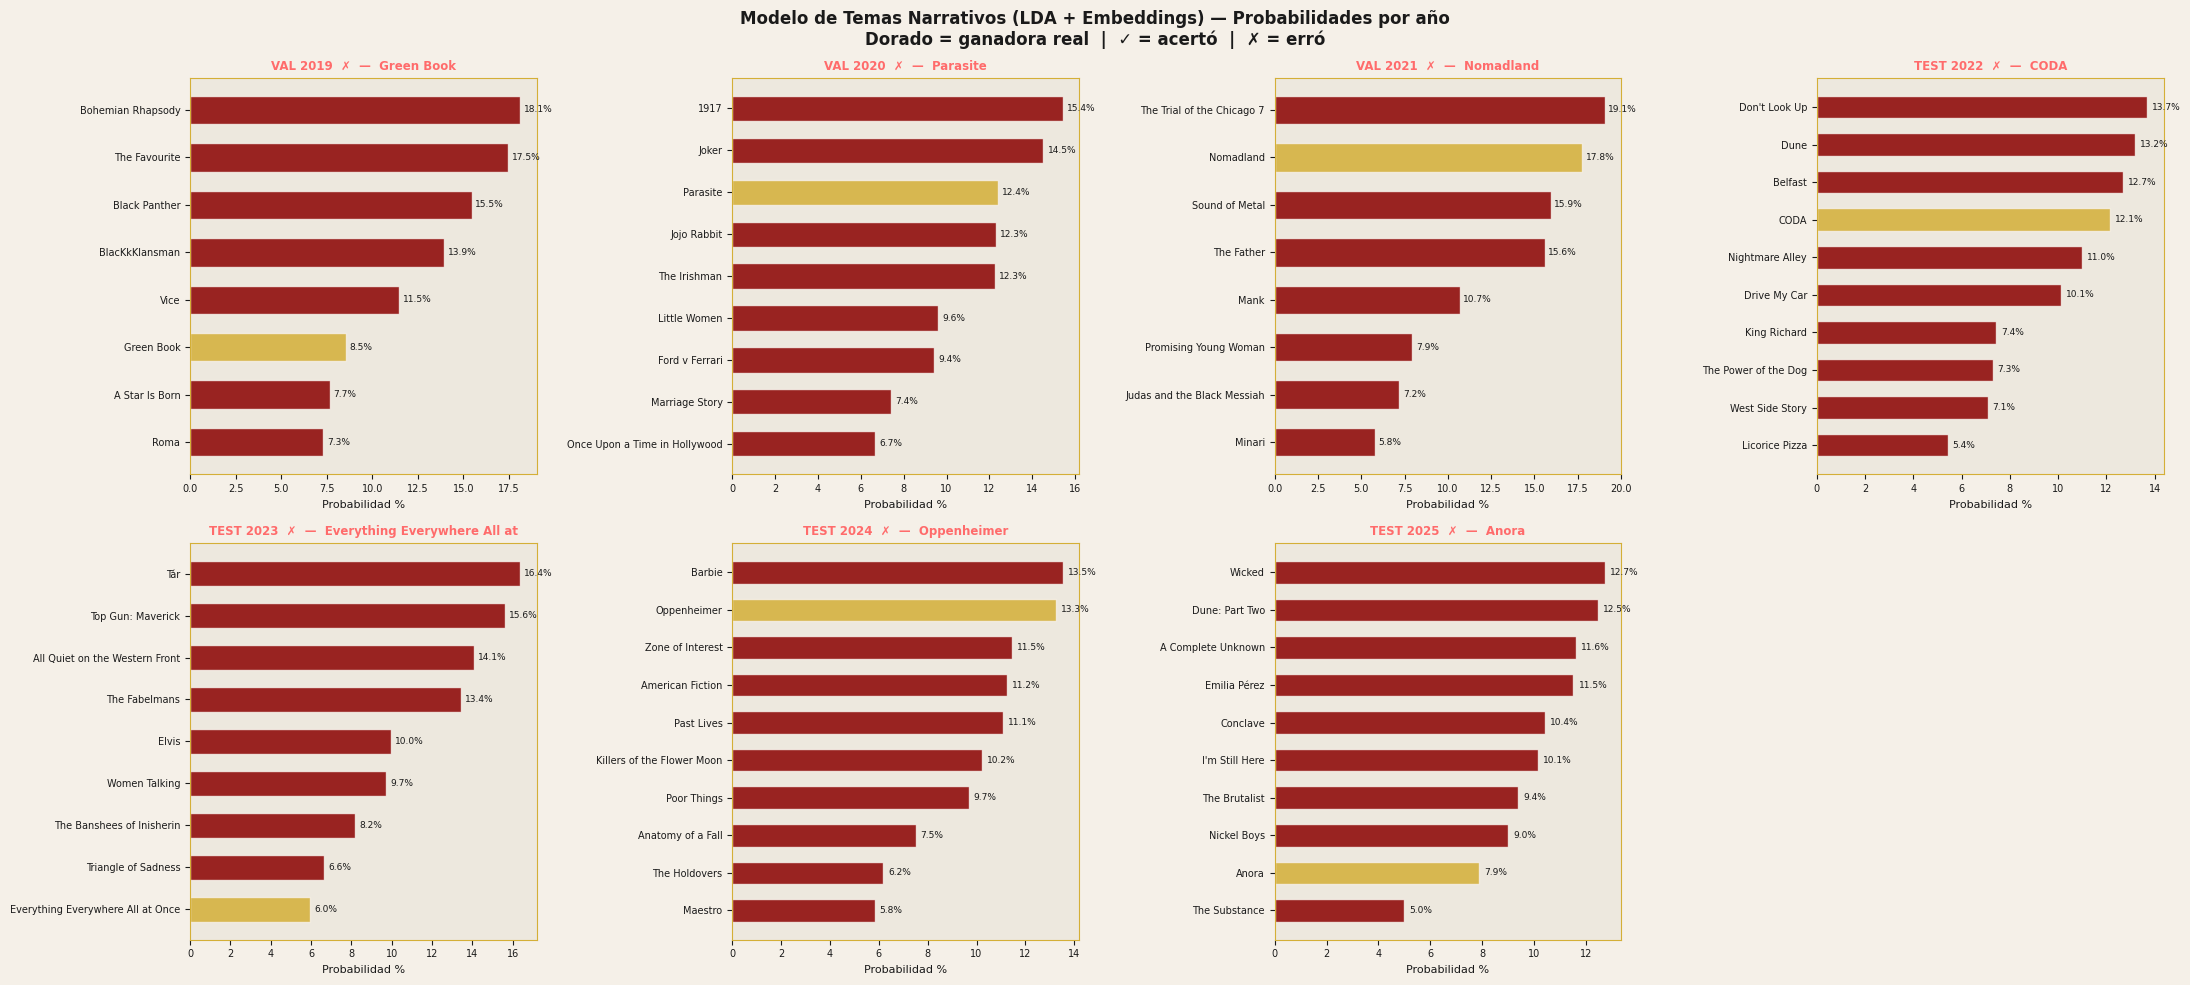

In [25]:
all_years  = val_years  + test_years
all_frames = [df_val_plot] * len(val_years) + [df_test_plot] * len(test_years)

n_cols = 4
n_rows = (len(all_years) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, n_rows * 5))
axes = axes.flatten()

for ax, year, src in zip(axes, all_years, all_frames):
    yd  = src[src["ceremony_year"] == year].sort_values("prob", ascending=True)
    probs      = yd["prob"].values * 100
    bar_colors = [GOLD if w == 1 else DARK_RED for w in yd["won_best_picture"].values]

    bars = ax.barh(yd["nominated_title"].tolist(), probs,
                   color=bar_colors, alpha=0.85, edgecolor=BG, height=0.6)

    winner = yd[yd["won_best_picture"] == 1]["nominated_title"].values[0]
    pred   = yd.sort_values("prob", ascending=False).iloc[0]["nominated_title"]
    wp     = yd[yd["won_best_picture"] == 1]["prob"].values[0] * 100
    ok     = winner == pred
    split  = "TEST" if year in test_years else "VAL"

    ax.set_title(f"{split} {year}  {'✓' if ok else '✗'}  —  {winner[:28]}",
                 color=GOLD if ok else "#FF6B6B", fontsize=8.5, fontweight="bold")
    ax.set_xlabel("Probabilidad %", color=TEXT, fontsize=8)
    ax.tick_params(colors=TEXT, labelsize=7)
    ax.set_facecolor(PANEL_BG)
    for spine in ax.spines.values(): spine.set_edgecolor(GOLD)
    for bar, val in zip(bars, probs):
        ax.text(val + 0.2, bar.get_y() + bar.get_height() / 2,
                f"{val:.1f}%", va="center", fontsize=6.5, color=TEXT)

for ax in axes[len(all_years):]:
    ax.set_visible(False)

fig.patch.set_facecolor(BG)
plt.suptitle("Modelo de Temas Narrativos (LDA + Embeddings) — Probabilidades por año\n"
             "Dorado = ganadora real  |  ✓ = acertó  |  ✗ = erró",
             fontsize=12, color=TEXT, fontweight="bold")
plt.tight_layout()
plt.savefig("img/topics_model_all_years.png", dpi=130, bbox_inches="tight", facecolor=BG)
plt.show()
